# FFT Analysis

After deriving a theoretical value for the frequency at which my mug resonates at, it is now time to work out an experimental value. I have recorded a series of dings I made to the mug to make a note resonate using a steel knife, as this minimizes any muffling upon striking impact while also being aggressive enough to have the note ring out with measurable duration. After uploading my audio, my first step is to convert the file to mono as most iPhone videos originate as stereo recordings.

## Mono and Normalization

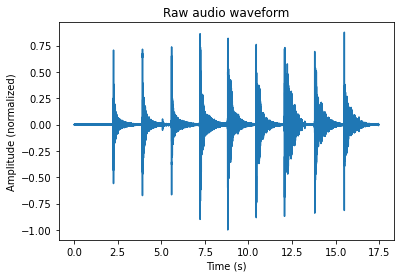

<Figure size 432x288 with 0 Axes>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

def mono(x):
    x = np.asarray(x)
    return x.astype(np.float64) if x.ndim == 1 else x.mean(axis=1).astype(np.float64)

def normalize_and_detrend(x):
    x = x - np.mean(x)
    m = np.max(np.abs(x)) + 1e-12
    return x / m

wav = 'mug_test.wav'

fs, x = wavfile.read(wav)
x = mono(x)

if np.issubdtype(x.dtype, np.integer):
    x = x / np.iinfo(x.dtype).max

trim = 1.5
n_trim = int(trim*fs)
x = x[:-n_trim]
    
x = normalize_and_detrend(x)
t = np.arange(len(x)) / fs

plt.figure()
plt.plot(t, x)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (normalized)")
plt.title("Raw audio waveform")
plt.show()
plt.savefig('mono_norm_plot.jpeg')

## High-Pass Filtration
Just to refine our data going forward in case there were any extra frequencies influencing our plot.

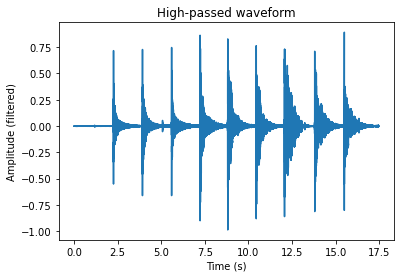

In [4]:
from scipy.signal import butter, filtfilt

def highpass(x, fs, cutoff_hz=100.0, order=4):
    b, a = butter(order, cutoff_hz/(fs/2), btype='highpass')
    return filtfilt(b, a, x)

x_hp = highpass(x, fs, cutoff_hz=100.0)

plt.figure()
plt.plot(t, x_hp)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (filtered)")
plt.title("High-passed waveform")
plt.show()

## Peak Identification

Using scipy package to locate specific peaks in our data. I took multiple samples with the intent of eventually calculating mean/SD for a more refined result.

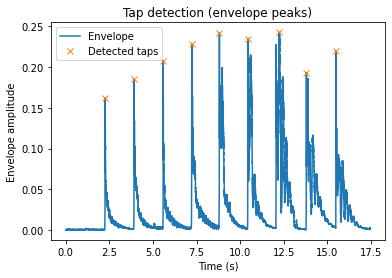

In [5]:
from scipy.signal import find_peaks

abs_sig = np.abs(x_hp)
win = max(int(0.01 * fs), 1)
env = np.convolve(abs_sig, np.ones(win)/win, mode='same')

peaks, props = find_peaks(env,
                          height=np.percentile(env, 95),
                          distance=int(0.25 * fs))

keep = 9
order = np.argsort(props["peak_heights"])[::-1]
peaks = peaks[order][:keep]
#tap_indices = peaks[order][:keep]

plt.figure()
plt.plot(t, env, label="Envelope")
plt.plot(t[peaks], env[peaks], "x", label="Detected taps")
plt.xlabel("Time (s)")
plt.ylabel("Envelope amplitude")
plt.title("Tap detection (envelope peaks)")
plt.legend()
plt.show()

## "Click" Skipping
The sharp strike that excites the mug contains a broadband click that is not the same thing as the mug's natural ringing. Here, detected tap is trimmed into a ringdown segment that begins just after the impact transient so that the later FFT focuses on the decaying resonance of the structure itself.

In [8]:
def extract_ringdown(x, fs, p, start_delay_s=0.02, duration_s=0.60):
    start = int(p + start_delay_s*fs)
    end = int(start + duration_s*fs)
    if end > len(x):
        return None
    seg = x[start:end]
    return seg - np.mean(seg)

segments = [extract_ringdown(x_hp, fs, p) for p in peaks]
segments = [s for s in segments if s is not None]
print("Segments:", len(segments))

Segments: 9


## FFT with Hann Windowing
Each ringdown segment is coverted into the frequency domain. A Hann window is applied first to taper the ends of the signal and reduce leakage so that the peaks in the FFT more cleanly reflect the mug's resonant frequencies.

In [9]:
from scipy.signal import windows

def spectrum(seg, fs):
    w = windows.hann(len(seg))
    segw = seg * w
    freqs = np.fft.rfftfreq(len(segw), d=1/fs)
    spec = np.abs(np.fft.rfft(segw))
    return freqs, spec

## Finding Dominant Resonance Peak via Parabolic Interpolation
Defining search band for frequencies.

In [10]:
def parabolic_peak(freqs, mags, k):
    if k <= 0 or k >= len(mags)-1:
        return freqs[k]
    y0, y1, y2 = mags[k-1], mags[k], mags[k+1]
    y0, y1, y2 = np.maximum([y0, y1, y2], 1e-12)
    l0, l1, l2 = np.log(y0), np.log(y1), np.log(y2)

    denom = (l0 - 2*l1 + l2)
    if abs(denom) < 1e-12:
        return freqs[k]

    delta = 0.5*(l0 - l2)/denom
    df = freqs[1] - freqs[0]
    return freqs[k] + delta*df

def dominant_peak(freqs, spec, fmin=200, fmax=2000):
    band = (freqs >= fmin) & (freqs <= fmax)
    idx = np.where(band)[0]
    k = idx[np.argmax(spec[band])]
    fpk = parabolic_peak(freqs, spec, k)
    return fpk, k

## Mapping Peak to Musical Note
Using cents for fine tuning.

In [11]:
NOTES = ["C","C#","D","D#","E","F","F#","G","G#","A","A#","B"]

def freq_to_note(f, a4=440.0):
    midi = 69 + 12*np.log2(f/a4)
    midi_round = int(np.round(midi))
    note_freq = a4 * 2**((midi_round - 69)/12)
    cents = 1200*np.log2(f/note_freq)
    name = NOTES[midi_round % 12]
    octave = midi_round//12 - 1
    return f"{name}{octave}", note_freq, cents

## Putting It All Together

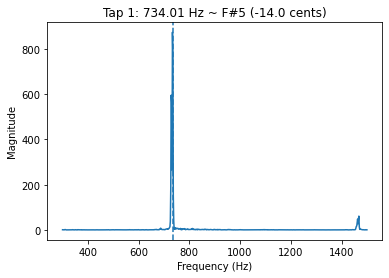

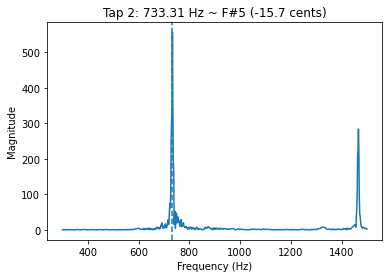

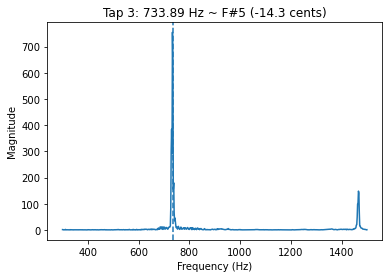

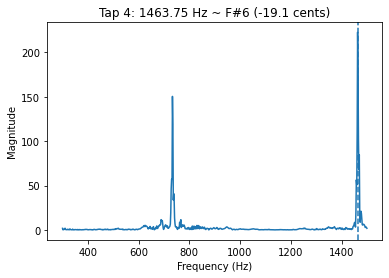

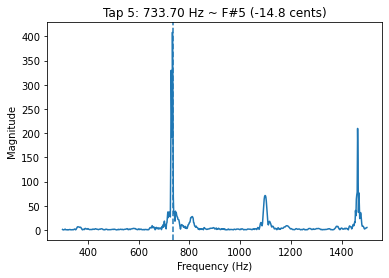

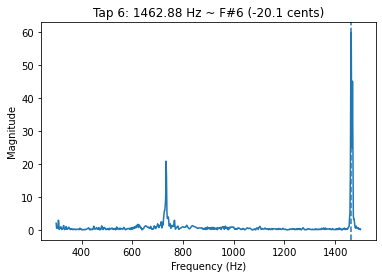

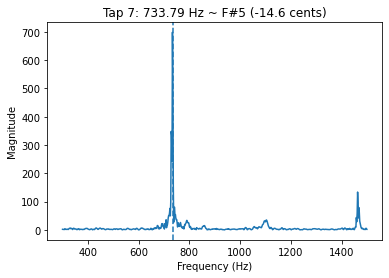

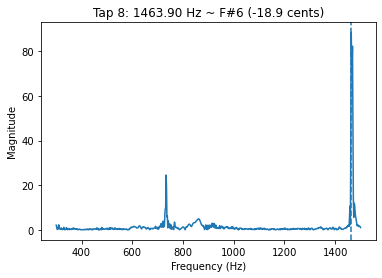

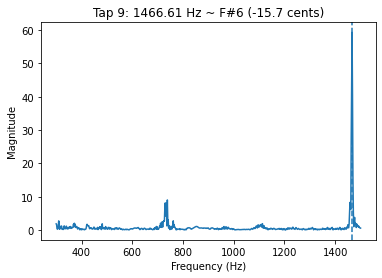


Peak summary across taps:
  Tap 1: 734.01 Hz -> F#5 (-14.0 cents)
  Tap 2: 733.31 Hz -> F#5 (-15.7 cents)
  Tap 3: 733.89 Hz -> F#5 (-14.3 cents)
  Tap 4: 1463.75 Hz -> F#6 (-19.1 cents)
  Tap 5: 733.70 Hz -> F#5 (-14.8 cents)
  Tap 6: 1462.88 Hz -> F#6 (-20.1 cents)
  Tap 7: 733.79 Hz -> F#5 (-14.6 cents)
  Tap 8: 1463.90 Hz -> F#6 (-18.9 cents)
  Tap 9: 1466.61 Hz -> F#6 (-15.7 cents)

Fundamental:
  Fundamental peak 1: 734.01 Hz -> F#5 (-14.0 cents)
  Fundamental peak 2: 733.31 Hz -> F#5 (-15.7 cents)
  Fundamental peak 3: 733.89 Hz -> F#5 (-14.3 cents)
  Fundamental peak 4: 733.70 Hz -> F#5 (-14.8 cents)
  Fundamental peak 5: 733.79 Hz -> F#5 (-14.6 cents)
  Mean f: 733.74 Hz
  Std  f:  0.27 Hz

Harmonic:
  Harmonic peak 1: 1463.75 Hz -> F#6 (-19.1 cents)
  Harmonic peak 2: 1462.88 Hz -> F#6 (-20.1 cents)
  Harmonic peak 3: 1463.90 Hz -> F#6 (-18.9 cents)
  Harmonic peak 4: 1466.61 Hz -> F#6 (-15.7 cents)
  Mean f: 1464.29 Hz
  Std  f:  1.62 Hz


In [13]:
results = []

for i, seg in enumerate(segments, start=1):
    freqs, spec = spectrum(seg, fs)
    fpk, k = dominant_peak(freqs, spec, fmin=300, fmax=1500)
    note, note_f, cents = freq_to_note(fpk)
    results.append((fpk, note, cents))

    # quick diagnostic plot
    band = (freqs >= 300) & (freqs <= 1500)
    plt.figure()
    plt.plot(freqs[band], spec[band])
    plt.axvline(fpk, linestyle="--")
    plt.title(f"Tap {i}: {fpk:.2f} Hz ~ {note} ({cents:+.1f} cents)")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.show()

fvals = np.array([r[0] for r in results])

# clustering by frequency threshold
split_freq = 1000.0
fundamental = [r for r in results if r[0] < split_freq]
harmonic = [r for r in results if r[0] >= split_freq]

print("\nPeak summary across taps:")
for i, (fpk, note, cents) in enumerate(results, start=1):
    print(f"  Tap {i}: {fpk:.2f} Hz -> {note} ({cents:+.1f} cents)")

def summarize_cluster(name, cluster):
    if len(cluster) == 0:
        print(f"\n{name}: no peaks found")
        return

    vals = np.array([r[0] for r in cluster])
    print(f"\n{name}:")
    for i, (fpk, note, cents) in enumerate(cluster, start=1):
        print(f"  {name} peak {i}: {fpk:.2f} Hz -> {note} ({cents:+.1f} cents)")
    print(f"  Mean f: {vals.mean():.2f} Hz")
    print(f"  Std  f:  {vals.std(ddof=1) if len(vals) > 1 else 0:.2f} Hz")

summarize_cluster("Fundamental", fundamental)
summarize_cluster("Harmonic", harmonic)

In [2]:
!mkdir -p mug-resonance/report mug-resonance/code mug-resonance/data
!ls mug-resonance

code   data   report
